# Libraries and Imports

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn 
import torch
import torch_geometric
import gymnasium as gym
import stable_baselines3
import random
import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from gymnasium import spaces
from stable_baselines3 import DDPG, TD3
from stable_baselines3.common.callbacks import BaseCallback
import copy
from collections import deque
from torch_geometric.data import Data
from torch_geometric.utils import to_dense_adj
from scipy.sparse.csgraph import shortest_path

# Environment

In [37]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import networkx as nx


class MECEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        num_servers=5,
        num_tasks_per_slot=10,
        episode_length=200,
        seed=42
    ):

        super(MECEnv, self).__init__()

        # =========================================================
        # BASIC PARAMETERS
        # =========================================================

        self.M = num_servers               # edge servers
        self.N = num_tasks_per_slot
        self.delta_t = 0.1
        self.episode_length = episode_length

        self.current_step = 0

        self.rng = np.random.default_rng(seed)

        # =========================================================
        # NETWORK TOPOLOGY
        # =========================================================

        self.G = nx.fast_gnp_random_graph(
            self.M + 1,
            0.6,
            seed=seed
        )

        while not nx.is_connected(self.G):
            self.G = nx.fast_gnp_random_graph(
                self.M + 1,
                0.6
            )

        for (u, v) in self.G.edges():
            self.G.edges[u, v]["bandwidth"] = self.rng.uniform(50, 150)

        # =========================================================
        # SERVER CAPACITY (GHz)
        # =========================================================

        self.server_capacities = np.array(
            [250.0] +
            [self.rng.uniform(50, 150) for _ in range(self.M)],
            dtype=np.float32
        )

        # remaining queued CPU cycles
        self.server_queues = np.zeros(self.M + 1, dtype=np.float32)

        # =========================================================
        # CONTINUOUS ACTION SPACE
        # Compatible with TD3/DDPG/SAC/PPO
        # =========================================================

        # For each task:
        # [server_selection, vm_level]
        #
        # both in [0,1]

        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(self.N, 2),
            dtype=np.float32
        )

        # =========================================================
        # OBSERVATION SPACE
        # =========================================================

        # each task:
        # [data_size, cpu_cycles, deadline, entry_node]

        obs_dim = self.N * 4 + (self.M + 1)

        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(obs_dim,),
            dtype=np.float32
        )

        self.current_tasks = None

    # =============================================================
    # TASK GENERATION
    # =============================================================

    def _generate_tasks(self):

        tasks = []

        for _ in range(self.N):

            # data size (Mb)
            y_r = self.rng.uniform(10, 30)

            # cpu cycles
            xi_r = y_r * 1e6 * self.rng.uniform(500, 1100)

            # deadline
            L_r = self.rng.uniform(0.5, 1.5)

            # entry node
            entry_node = self.rng.integers(1, self.M + 1)

            tasks.append([
                y_r,
                xi_r,
                L_r,
                entry_node
            ])

        return np.array(tasks, dtype=np.float32)

    # =============================================================
    # ROUTING METRICS
    # =============================================================

    def _get_routing_metrics(
        self,
        start_node,
        end_node,
        data_size
    ):

        if start_node == end_node:
            return 0.0, 0.0

        try:

            path = nx.shortest_path( # تقلب nx.shortest_path(..., weight="delay")
                self.G,
                source=int(start_node),
                target=int(end_node)
            )

            delay = 0.0
            total_flow = 0.0

            for i in range(len(path) - 1):

                u, v = path[i], path[i + 1]

                bw = self.G.edges[u, v]["bandwidth"]

                delay += data_size / bw

                total_flow += data_size

            return delay, total_flow

        except nx.NetworkXNoPath:

            return 1e3, 0.0

    # =============================================================
    # ACTION DISCRETIZATION
    # =============================================================

    def _decode_action(self, action):

        decoded = []

        for i in range(self.N):

            server_cont = action[i, 0]
            vm_cont = action[i, 1]

            # server selection
            target_server = int(server_cont * self.M)
            target_server = np.clip(
                target_server,
                0,
                self.M
            )

            # vm level: 1..5
            vm_level = int(vm_cont * 4) + 1
            vm_level = np.clip(
                vm_level,
                1,
                5
            )

            decoded.append([target_server, vm_level])

        return np.array(decoded)

    # =============================================================
    # OBSERVATION
    # =============================================================

    def _get_obs(self):

        tasks = self.current_tasks.copy()

        # normalization

        # data size
        tasks[:, 0] /= 30.0

        # cpu cycles
        tasks[:, 1] /= 3e10

        # deadline
        tasks[:, 2] /= 2.0

        # entry node
        tasks[:, 3] /= (self.M + 1)

        queues = self.server_queues / 1e11

        obs = np.concatenate([
            tasks.flatten(),
            queues
        ])

        obs = np.clip(obs, 0.0, 1.0)

        return obs.astype(np.float32)

    # =============================================================
    # STEP
    # =============================================================

    def step(self, action):

        self.current_step += 1

        action = np.asarray(action)

        decoded_action = self._decode_action(action)

        step_delays = []
        step_energies = []

        step_throughput = 0.0

        success_count = 0

        # ---------------------------------------------------------
        # group tasks per server
        # ---------------------------------------------------------

        server_assignments = {
            i: [] for i in range(self.M + 1)
        }

        for i in range(self.N):

            target_server = decoded_action[i, 0]

            server_assignments[target_server].append(i)

        # ---------------------------------------------------------
        # execute tasks
        # ---------------------------------------------------------

        for j in range(self.M + 1):

            assigned_tasks = server_assignments[j]

            num_tasks = len(assigned_tasks)

            if num_tasks == 0:
                continue

            total_capacity = self.server_capacities[j]

            for idx in assigned_tasks:

                vm_level = decoded_action[idx, 1]

                y_r, xi_r, L_r, entry_node = \
                    self.current_tasks[idx]

                # -------------------------------------------------
                # allocated frequency
                # -------------------------------------------------

                f_rj = (
                    total_capacity /
                    (num_tasks * 5)
                ) * vm_level

                f_rj = max(f_rj, 1e-6)

                # -------------------------------------------------
                # transmission
                # -------------------------------------------------

                t_trans, flow = self._get_routing_metrics(
                    entry_node,
                    j,
                    y_r
                )

                step_throughput += flow

                # -------------------------------------------------
                # waiting time
                # -------------------------------------------------

                current_queue = self.server_queues[j]

                t_wait = current_queue / (
                    total_capacity * 1e9
                )

                # -------------------------------------------------
                # computation
                # -------------------------------------------------

                t_comp = xi_r / (f_rj * 1e9)

                total_t = (
                    t_trans +
                    t_wait +
                    t_comp
                )

                # -------------------------------------------------
                # energy
                # -------------------------------------------------

                e_trans = 0.1 * t_trans

                e_comp = (
                    1e-27 *
                    (f_rj ** 2) *
                    xi_r
                )

                total_e = e_trans + e_comp

                step_delays.append(total_t)
                step_energies.append(total_e)

                # -------------------------------------------------
                # success
                # -------------------------------------------------

                if total_t <= L_r:
                    success_count += 1

                # -------------------------------------------------
                # update queue
                # -------------------------------------------------

                self.server_queues[j] += xi_r

        # ---------------------------------------------------------
        # queue draining
        # ---------------------------------------------------------

        for j in range(self.M + 1):

            processed = (
                self.server_capacities[j] *
                1e9 *
                self.delta_t
            )

            self.server_queues[j] = max(
                0.0,
                self.server_queues[j] - processed
            )

        # ---------------------------------------------------------
        # metrics
        # ---------------------------------------------------------

        avg_delay = (
            np.mean(step_delays)
            if step_delays else 10.0
        )

        avg_energy = (
            np.mean(step_energies)
            if step_energies else 1.0
        )

        success_rate = success_count / self.N

        # ---------------------------------------------------------
        # STABLE NORMALIZED REWARD
        # ---------------------------------------------------------

        reward = (
            2.0 * success_rate
            - 0.1 * avg_delay
            - 0.01 * avg_energy
        )

        reward = float(np.clip(reward, -10, 10))

        # ---------------------------------------------------------
        # next state
        # ---------------------------------------------------------

        self.current_tasks = self._generate_tasks()

        terminated = False

        truncated = (
            self.current_step >= self.episode_length
        )

        info = {

            "avg_delay": float(avg_delay),

            "avg_energy": float(avg_energy),

            "success_rate": float(success_rate),

            "throughput": float(step_throughput),

            "queue_mean": float(
                np.mean(self.server_queues)
            ),

            "energy_total": float(
                np.sum(step_energies)
            )
        }

        return (
            self._get_obs(),
            reward,
            terminated,
            truncated,
            info
        )

    # =============================================================
    # RESET
    # =============================================================

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.current_step = 0

        self.server_queues = np.zeros(
            self.M + 1,
            dtype=np.float32
        )

        self.current_tasks = self._generate_tasks()

        return self._get_obs(), {}

    # =============================================================
    # RENDER
    # =============================================================

    def render(self):
        return
        print(
            f"Step={self.current_step} | "
            f"Queue Mean={np.mean(self.server_queues):.2e}")
    # =============================================================
    # CLONE STATE
    # =============================================================
    
    def clone_state(self):
    
        """
        Snapshot minimal environment state
        required for deterministic rollback.
        """
    
        state = {
    
            # -----------------------------------------------------
            # simulation step
            # -----------------------------------------------------
    
            "current_step": self.current_step,
    
            # -----------------------------------------------------
            # queues
            # -----------------------------------------------------
    
            "server_queues": self.server_queues.copy(),
    
            # -----------------------------------------------------
            # current tasks
            # -----------------------------------------------------
    
            "current_tasks": self.current_tasks.copy(),
    
            # -----------------------------------------------------
            # RNG state
            # VERY IMPORTANT
            # -----------------------------------------------------
    
            "rng_state": copy.deepcopy(
                self.rng.bit_generator.state
            )
        }
    
        return state
    
    
    # =============================================================
    # RESTORE STATE
    # =============================================================
    
    def restore_state(self, state):
    
        """
        Restore environment snapshot.
        """
    
        # ---------------------------------------------------------
        # simulation step
        # ---------------------------------------------------------
    
        self.current_step = state["current_step"]
    
        # ---------------------------------------------------------
        # queues
        # ---------------------------------------------------------
    
        self.server_queues = state[
            "server_queues"
        ].copy()
    
        # ---------------------------------------------------------
        # current tasks
        # ---------------------------------------------------------
    
        self.current_tasks = state[
            "current_tasks"
        ].copy()
    
        # ---------------------------------------------------------
        # RNG
        # ---------------------------------------------------------
    
        self.rng.bit_generator.state = \
            copy.deepcopy(state["rng_state"])

# Greedy

# OO-DDPG

![comp](comparison.png)

In [38]:
# ============================================================
# REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(self, capacity=100000):

        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        if len(self.buffer) < self.capacity:
            self.buffer.append(None)

        self.buffer[self.position] = (
            state,
            action,
            reward,
            next_state,
            done
        )

        self.position = (
            self.position + 1
        ) % self.capacity

    def sample(self, batch_size):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        state, action, reward, next_state, done = map(
            np.stack,
            zip(*batch)
        )

        return (
            state,
            action,
            reward,
            next_state,
            done
        )

    def __len__(self):

        return len(self.buffer)


# ============================================================
# ACTOR NETWORK
# ============================================================

class Actor(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=256
    ):

        super(Actor, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, action_dim),
            nn.Sigmoid()
        )

    def forward(self, state):

        return self.net(state)


# ============================================================
# CRITIC NETWORK
# ============================================================

class Critic(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=256
    ):

        super(Critic, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(
                state_dim + action_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),

            nn.ReLU(),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state, action):

        x = torch.cat([state, action], dim=1)

        return self.net(x)




# ============================================================
# OODDPG AGENT (PAPER-FAITHFUL VERSION)
# ============================================================

class OODDPG:

    def __init__(
        self,
        state_dim,
        action_dim,
        device="cuda" if torch.cuda.is_available() else "cpu"
    ):

        self.device = device

        # ----------------------------------------------------
        # Networks
        # ----------------------------------------------------

        self.actor = Actor(
            state_dim,
            action_dim
        ).to(device)

        self.actor_target = copy.deepcopy(
            self.actor
        )

        self.critic = Critic(
            state_dim,
            action_dim
        ).to(device)

        self.critic_target = copy.deepcopy(
            self.critic
        )

        # ----------------------------------------------------
        # Optimizers
        # ----------------------------------------------------

        self.actor_optimizer = optim.Adam(
            self.actor.parameters(),
            lr=1e-4
        )

        self.critic_optimizer = optim.Adam(
            self.critic.parameters(),
            lr=1e-3
        )

        # ----------------------------------------------------
        # Replay Buffer
        # ----------------------------------------------------

        self.replay_buffer = ReplayBuffer()

        # ----------------------------------------------------
        # Hyperparameters
        # ----------------------------------------------------

        self.gamma = 0.99

        self.tau = 0.005

        self.batch_size = 256

        # ----------------------------------------------------
        # OO PARAMETERS
        # ----------------------------------------------------

        # neighborhood size

        self.Na = 100

        # top candidates

        self.top_k = 5

        # binary mutation probability

        self.mutation_prob = 0.05

        # binary precision

        self.bits_per_dim = 8

        # env reference
        # set externally in wrapper

        self.env = None

    # ========================================================
    # BINARY ENCODING
    # ========================================================

    def encode_action(self, action):

        """
        continuous [0,1]
        ->
        binary vector
        """

        binary_code = []

        for x in action:

            value = int(
                x * (2**self.bits_per_dim - 1)
            )

            bits = np.binary_repr(
                value,
                width=self.bits_per_dim
            )

            binary_code.extend(
                [int(b) for b in bits]
            )

        return np.array(
            binary_code,
            dtype=np.int8
        )

    # ========================================================
    # BINARY DECODING
    # ========================================================

    def decode_action(self, binary_code):

        values = []

        for i in range(
            0,
            len(binary_code),
            self.bits_per_dim
        ):

            bits = binary_code[
                i:i+self.bits_per_dim
            ]

            bit_string = ''.join(
                bits.astype(str)
            )

            integer = int(
                bit_string,
                2
            )

            value = integer / (
                2**self.bits_per_dim - 1
            )

            values.append(value)

        return np.array(
            values,
            dtype=np.float32
        )

    # ========================================================
    # BINARY MUTATION
    # ========================================================

    def mutate_binary_action(
        self,
        binary_action
    ):

        mutated = binary_action.copy()

        mask = np.random.rand(
            len(mutated)
        ) < self.mutation_prob

        mutated[mask] = 1 - mutated[mask]

        return mutated

    # ========================================================
    # FAST CRITIC RANKING
    # ========================================================

    def rank_actions(
        self,
        state,
        candidate_actions
    ):

        state_repeat = np.repeat(
            state[None, :],
            len(candidate_actions),
            axis=0
        )

        state_tensor = torch.FloatTensor(
            state_repeat
        ).to(self.device)

        action_tensor = torch.FloatTensor(
            candidate_actions
        ).to(self.device)

        with torch.no_grad():

            q_values = self.critic(
                state_tensor,
                action_tensor
            ).cpu().numpy().flatten()

        return q_values

    # ========================================================
    # REAL ENVIRONMENT EVALUATION
    # ========================================================

    def evaluate_real_environment(
        self,
        state,
        candidate_actions
    ):

        """
        paper-faithful final evaluation
        """

        if self.env is None:

            # fallback
            return candidate_actions[0]

        best_score = -np.inf

        best_action = candidate_actions[0]

        # ---------------------------------------------
        # backup env state
        # ---------------------------------------------

        snapshot = self.env.clone_state()

        for action in candidate_actions:

            action_env = action.reshape(
                self.env.N,
                2
            )

            # -----------------------------------------
            # REAL STEP
            # -----------------------------------------

            _, reward, _, _, info = self.env.step(
                action_env
            )

            # multi-objective score

            score = (

                reward

                + 2.0 * info['success_rate']

                - 0.05 * info['avg_delay']

                - 0.01 * info['avg_energy']
            )

            if score > best_score:

                best_score = score

                best_action = action.copy()

            # -----------------------------------------
            # restore env
            # -----------------------------------------

            self.env.restore_state(snapshot)

        return best_action

    # ========================================================
    # SELECT ACTION
    # ========================================================

    def select_action(self, state):

        state_tensor = torch.FloatTensor(
            state
        ).unsqueeze(0).to(self.device)

        # ----------------------------------------------------
        # Actor Base Action
        # ----------------------------------------------------

        with torch.no_grad():

            base_action = self.actor(
                state_tensor
            ).cpu().numpy()[0]

        # ====================================================
        # STEP 1:
        # BINARY ENCODING
        # ====================================================

        binary_base = self.encode_action(
            base_action
        )

        # ====================================================
        # STEP 2:
        # GENERATE 100 MUTATIONS
        # ====================================================

        candidate_actions = []

        for _ in range(self.Na):

            mutated_binary = self.mutate_binary_action(
                binary_base
            )

            candidate = self.decode_action(
                mutated_binary
            )

            candidate = np.clip(
                candidate,
                0.0,
                1.0
            )

            candidate_actions.append(candidate)

        candidate_actions = np.array(
            candidate_actions,
            dtype=np.float32
        )

        # ====================================================
        # STEP 3:
        # CRITIC PRE-RANKING
        # ====================================================

        q_values = self.rank_actions(
            state,
            candidate_actions
        )

        # ====================================================
        # STEP 4:
        # TOP-K SELECTION
        # ====================================================

        top_indices = np.argsort(
            q_values
        )[-self.top_k:]

        top_actions = candidate_actions[
            top_indices
        ]

        # ====================================================
        # STEP 5:
        # REAL ENVIRONMENT EVALUATION
        # ====================================================

        final_action = self.evaluate_real_environment(
            state,
            top_actions
        )

        return final_action

    # ========================================================
    # TRAIN
    # ========================================================

    def train(self):

        if len(self.replay_buffer) < self.batch_size:
            return

        (
            states,
            actions,
            rewards,
            next_states,
            dones
        ) = self.replay_buffer.sample(
            self.batch_size
        )

        states = torch.FloatTensor(
            states
        ).to(self.device)

        actions = torch.FloatTensor(
            actions
        ).to(self.device)

        rewards = torch.FloatTensor(
            rewards
        ).unsqueeze(1).to(self.device)

        next_states = torch.FloatTensor(
            next_states
        ).to(self.device)

        dones = torch.FloatTensor(
            dones
        ).unsqueeze(1).to(self.device)

        # ----------------------------------------------------
        # TARGET Q
        # ----------------------------------------------------

        with torch.no_grad():

            next_actions = self.actor_target(
                next_states
            )

            target_q = self.critic_target(
                next_states,
                next_actions
            )

            target_q = rewards + (
                1 - dones
            ) * self.gamma * target_q

        # ----------------------------------------------------
        # CRITIC LOSS
        # ----------------------------------------------------

        current_q = self.critic(
            states,
            actions
        )

        critic_loss = nn.MSELoss()(
            current_q,
            target_q
        )

        self.critic_optimizer.zero_grad()

        critic_loss.backward()

        self.critic_optimizer.step()

        # ----------------------------------------------------
        # ACTOR LOSS
        # ----------------------------------------------------

        actor_loss = -self.critic(
            states,
            self.actor(states)
        ).mean()

        self.actor_optimizer.zero_grad()

        actor_loss.backward()

        self.actor_optimizer.step()

        # ----------------------------------------------------
        # SOFT UPDATE
        # ----------------------------------------------------

        self.soft_update(
            self.actor,
            self.actor_target
        )

        self.soft_update(
            self.critic,
            self.critic_target
        )

    # ========================================================
    # SOFT UPDATE
    # ========================================================

    def soft_update(
        self,
        net,
        target_net
    ):

        for param, target_param in zip(
            net.parameters(),
            target_net.parameters()
        ):

            target_param.data.copy_(

                self.tau * param.data +

                (1 - self.tau)
                * target_param.data
            )

In [39]:
class OODDPGWrapper:

    def __init__(
        self,
        env,
        total_timesteps=5_000
    ):

        self.env = env

        state_dim = env.observation_space.shape[0]

        action_dim = np.prod(
            env.action_space.shape
        )

        self.agent = OODDPG(
            state_dim,
            action_dim
        )
        self.agent.env = env
        self.total_timesteps = total_timesteps

    # =====================================================
    # TRAIN
    # =====================================================

    def learn(self):

        state, _ = self.env.reset()

        done = False

        timestep = 0

        episode_reward = 0

        rewards_history = []

        while timestep < self.total_timesteps:

            # ---------------------------------------------
            # SELECT ACTION
            # ---------------------------------------------

            action = self.agent.select_action(
                state
            )

            action_env = action.reshape(
                self.env.N,
                2
            )

            # ---------------------------------------------
            # ENV STEP
            # ---------------------------------------------

            next_state, reward, terminated, truncated, info = \
                self.env.step(action_env)

            done = terminated or truncated

            # ---------------------------------------------
            # STORE
            # ---------------------------------------------

            self.agent.replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done)
            )

            # ---------------------------------------------
            # TRAIN
            # ---------------------------------------------

            self.agent.train()

            state = next_state

            episode_reward += reward

            timestep += 1

            # ---------------------------------------------
            # RESET
            # ---------------------------------------------

            if done:

                rewards_history.append(
                    episode_reward
                )

                state, _ = self.env.reset()

                done = False

                episode_reward = 0

        self.rewards_history = rewards_history

    # =====================================================
    # PREDICT
    # =====================================================

    def predict(self, state):

        action = self.agent.select_action(
            state
        )

        action = action.reshape(
            self.env.N,
            2
        )

        return action, None

# Experiments

In [40]:
import numpy as np
import matplotlib.pyplot as plt


def smooth(y, window=10):

    if len(y) < window:
        return y

    kernel = np.ones(window) / window

    y_smooth = np.convolve(
        y,
        kernel,
        mode='valid'
    )

    pad = [y_smooth[0]] * (window - 1)

    return np.concatenate([pad, y_smooth])


def plot_curves(
    X,
    Y,
    labels,
    title='',
    x_name='X',
    y_name='Y',
    smooth_window=10,
    figsize=(8,5)
):

    plt.figure(figsize=figsize, dpi=150)

    for x, y, label in zip(X, Y, labels):

        y = smooth(y, smooth_window)

        plt.plot(
            x,
            y,
            linewidth=2.5,
            label=label
        )

    plt.xlabel(x_name, fontsize=12)

    plt.ylabel(y_name, fontsize=12)

    plt.title(title, fontsize=14)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend(fontsize=11)

    plt.tight_layout()

    plt.show()

In [41]:
class RandomAgent:

    def __init__(self, env):

        self.env = env

    def predict(self, state):

        action = self.env.action_space.sample()

        return action, None


class GreedyAgent:

    def __init__(self, env):

        self.env = env

    def predict(self, state):

        queues = self.env.server_queues

        capacities = self.env.server_capacities

        score = queues / capacities

        best_server = np.argmin(score)

        actions = []

        for _ in range(self.env.N):

            server_norm = best_server / self.env.M

            vm_level = 1.0

            actions.append([
                server_norm,
                vm_level
            ])

        action = np.array(
            actions,
            dtype=np.float32
        )

        return action, None

In [42]:
from stable_baselines3 import DDPG, TD3
from stable_baselines3.common.noise import NormalActionNoise


def train_rl_agent(
    algo,
    env,
    total_timesteps=5000,
    seed=42
):

    # =====================================================
    # OODDPG
    # =====================================================

    if algo == "OODDPG":

        model = OODDPGWrapper(
            env,
            total_timesteps
        )

        model.learn()

        return model

    # =====================================================
    # SB3 ALGOS
    # =====================================================

    n_actions = env.action_space.shape[-1]

    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)
    )

    if algo == "DDPG":

        model = DDPG(
            "MlpPolicy",
            env,
            verbose=0,
            seed=seed,
            learning_rate=1e-4,
            batch_size=256,
            buffer_size=100000,
            learning_starts=1000,
            action_noise=action_noise
        )

    elif algo == "TD3":

        model = TD3(
            "MlpPolicy",
            env,
            verbose=0,
            seed=seed,
            learning_rate=1e-4,
            batch_size=256,
            buffer_size=100000,
            learning_starts=1000,
            action_noise=action_noise
        )

    else:

        raise ValueError("Unknown algo")

    model.learn(
        total_timesteps=total_timesteps,
        progress_bar=True
    )

    return model

In [43]:
def experiment_num_tasks():

    all_results = {}

    for N in EXPERIMENT_CONFIG[
        'tasks'
    ]:

        print(f"\n\nTASKS = {N}")

        def env_fn():

            return MECEnv(

                num_servers=5,

                num_tasks_per_slot=N
            )

        results = multi_seed_benchmark(

            env_fn,

            total_timesteps=
                EXPERIMENT_CONFIG['timesteps'],

            eval_episodes=
                EXPERIMENT_CONFIG['eval_episodes'],

            seeds=
                EXPERIMENT_CONFIG['seeds']
        )

        all_results[N] = results

    # -----------------------------------------------------
    # PLOTS
    # -----------------------------------------------------

    metrics = [

        'delay',

        'energy',

        'success_rate',

        'throughput',

        'reward'
    ]

    for metric in metrics:

        plot_metric(

            EXPERIMENT_CONFIG['tasks'],

            all_results,

            metric,

            f'{metric} vs Number of Tasks',

            'Number of Tasks'
        )

In [44]:
def evaluate_agent(
    env,
    agent,
    episodes=10
):

    rewards = []

    delays = []

    energies = []

    success_rates = []

    throughputs = []

    for _ in range(episodes):

        state, _ = env.reset()

        done = False

        ep_reward = 0

        ep_delay = []

        ep_energy = []

        ep_success = []

        ep_tp = []

        while not done:

            action, _ = agent.predict(
                state
            )

            next_state, reward, terminated, truncated, info = \
                env.step(action)

            done = terminated or truncated

            ep_reward += reward

            ep_delay.append(
                info['avg_delay']
            )

            ep_energy.append(
                info['avg_energy']
            )

            ep_success.append(
                info['success_rate']
            )

            ep_tp.append(
                info['throughput']
            )

            state = next_state

        rewards.append(ep_reward)

        delays.append(np.mean(ep_delay))

        energies.append(np.mean(ep_energy))

        success_rates.append(np.mean(ep_success))

        throughputs.append(np.mean(ep_tp))

    return {

        "reward":
            np.mean(rewards),

        "delay":
            np.mean(delays),

        "energy":
            np.mean(energies),

        "success_rate":
            np.mean(success_rates),

        "throughput":
            np.mean(throughputs)
    }

In [45]:
def benchmark_algorithms(
    env_fn,
    total_timesteps=5_000,
    eval_episodes=10,
    seed=42
):

    results = {}

    algos = [
        'Random',
        'Greedy',
        'DDPG',
        'TD3',
        'OODDPG'
    ]

    # =====================================================
    # RANDOM
    # =====================================================

    env = env_fn()

    random_agent = RandomAgent(env)

    results['Random'] = evaluate_agent(
        env,
        random_agent,
        eval_episodes
    )

    # =====================================================
    # GREEDY
    # =====================================================

    env = env_fn()

    greedy_agent = GreedyAgent(env)

    results['Greedy'] = evaluate_agent(
        env,
        greedy_agent,
        eval_episodes
    )

    # =====================================================
    # RL ALGORITHMS
    # =====================================================

    for algo in [

        'DDPG',

        'TD3',

        'OODDPG'
    ]:

        print(f"\nTraining {algo} ...")

        env = env_fn()

        model = train_rl_agent(
            algo,
            env,
            total_timesteps,
            seed
        )

        results[algo] = evaluate_agent(
            env,
            model,
            eval_episodes
        )

    return results

In [46]:
# =========================================================
# GLOBAL EXPERIMENT CONFIG
# =========================================================

EXPERIMENT_CONFIG = {

    # -----------------------------------------------------
    # TRAINING
    # -----------------------------------------------------

    "timesteps": 5000,

    "eval_episodes": 10,

    "seeds": [0,1,2],

    # -----------------------------------------------------
    # ENV PARAMETERS
    # -----------------------------------------------------

    "servers":

        [2,4,6,8,10,12,14,16],

    "tasks":

        [5,10,15,20,25,30,35,40],

    "bandwidth_scales":

        [0.25,0.5,0.75,1.0,1.5,2.0,2.5,3.0],

    "vm_noise":

        [0.01,0.03,0.05,0.07,0.1],

    "episode_lengths":

        [50,100,200,300,500],

    "deadline_scales":

        [0.5,0.75,1.0,1.25,1.5,2.0],

    "load_scales":

        [0.5,1.0,1.5,2.0,2.5,3.0],

    # -----------------------------------------------------
    # ALGORITHMS
    # -----------------------------------------------------

    "algorithms": [

        'Random',

        'Greedy',

        'DDPG',

        'TD3',

        'OODDPG'
    ]
}

In [47]:
def multi_seed_benchmark(
    env_fn,
    total_timesteps,
    eval_episodes,
    seeds
):

    final_results = {}

    algos = EXPERIMENT_CONFIG[
        'algorithms'
    ]

    for algo in algos:

        print(f"\n========== {algo} ==========")

        algo_metrics = {

            'reward': [],

            'delay': [],

            'energy': [],

            'success_rate': [],

            'throughput': []
        }

        for seed in seeds:

            print(f"Seed = {seed}")

            env = env_fn()

            # -----------------------------------------
            # RANDOM
            # -----------------------------------------

            if algo == 'Random':

                model = RandomAgent(env)

            elif algo == 'Greedy':

                model = GreedyAgent(env)

            else:

                model = train_rl_agent(
                    algo,
                    env,
                    total_timesteps,
                    seed
                )

            results = evaluate_agent(
                env,
                model,
                eval_episodes
            )

            for metric in algo_metrics:

                algo_metrics[metric].append(
                    results[metric]
                )

        final_results[algo] = {

            metric: {

                'mean':
                    np.mean(algo_metrics[metric]),

                'std':
                    np.std(algo_metrics[metric])

            }

            for metric in algo_metrics
        }

    return final_results

In [48]:
def plot_metric(
    x_values,
    results,
    metric,
    title,
    x_label
):

    plt.figure(figsize=(8,5), dpi=150)

    for algo in EXPERIMENT_CONFIG[
        'algorithms'
    ]:

        means = []

        stds = []

        for x in x_values:

            means.append(
                results[x][algo][metric]['mean']
            )

            stds.append(
                results[x][algo][metric]['std']
            )

        means = np.array(means)

        stds = np.array(stds)

        plt.plot(
            x_values,
            means,
            linewidth=2.5,
            label=algo
        )

        plt.fill_between(
            x_values,
            means - stds,
            means + stds,
            alpha=0.15
        )

    plt.xlabel(x_label)

    plt.ylabel(metric)

    plt.title(title)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [49]:
def experiment_num_tasks():

    all_results = {}

    for N in EXPERIMENT_CONFIG[
        'tasks'
    ]:

        print(f"\n\nTASKS = {N}")

        def env_fn():

            return MECEnv(

                num_servers=5,

                num_tasks_per_slot=N
            )

        results = multi_seed_benchmark(

            env_fn,

            total_timesteps=
                EXPERIMENT_CONFIG['timesteps'],

            eval_episodes=
                EXPERIMENT_CONFIG['eval_episodes'],

            seeds=
                EXPERIMENT_CONFIG['seeds']
        )

        all_results[N] = results

    # -----------------------------------------------------
    # PLOTS
    # -----------------------------------------------------

    metrics = [

        'delay',

        'energy',

        'success_rate',

        'throughput',

        'reward'
    ]

    for metric in metrics:

        plot_metric(

            EXPERIMENT_CONFIG['tasks'],

            all_results,

            metric,

            f'{metric} vs Number of Tasks',

            'Number of Tasks'
        )

In [50]:
def experiment_num_servers():

    all_results = {}

    for M in EXPERIMENT_CONFIG[
        'servers'
    ]:

        print(f"\n\nSERVERS = {M}")

        def env_fn():

            return MECEnv(

                num_servers=M,

                num_tasks_per_slot=10
            )

        results = multi_seed_benchmark(

            env_fn,

            total_timesteps=
                EXPERIMENT_CONFIG['timesteps'],

            eval_episodes=
                EXPERIMENT_CONFIG['eval_episodes'],

            seeds=
                EXPERIMENT_CONFIG['seeds']
        )

        all_results[M] = results

    metrics = [

        'delay',

        'energy',

        'success_rate',

        'throughput',

        'reward'
    ]

    for metric in metrics:

        plot_metric(

            EXPERIMENT_CONFIG['servers'],

            all_results,

            metric,

            f'{metric} vs Number of Servers',

            'Number of Servers'
        )

In [51]:
def experiment_bandwidth():

    all_results = {}

    for scale in EXPERIMENT_CONFIG[
        'bandwidth_scales'
    ]:

        print(f"\n\nBANDWIDTH = {scale}")

        def env_fn():

            env = MECEnv()

            for (u,v) in env.G.edges():

                env.G.edges[u,v][
                    'bandwidth'
                ] *= scale

            return env

        results = multi_seed_benchmark(

            env_fn,

            total_timesteps=
                EXPERIMENT_CONFIG['timesteps'],

            eval_episodes=
                EXPERIMENT_CONFIG['eval_episodes'],

            seeds=
                EXPERIMENT_CONFIG['seeds']
        )

        all_results[scale] = results

    metrics = [

        'delay',

        'energy',

        'success_rate',

        'throughput',

        'reward'
    ]

    for metric in metrics:

        plot_metric(

            EXPERIMENT_CONFIG[
                'bandwidth_scales'
            ],

            all_results,

            metric,

            f'{metric} vs Bandwidth',

            'Bandwidth Scale'
        )

In [52]:
def convergence_experiment():

    env = MECEnv()

    rewards = {}

    # =====================================================
    # DDPG
    # =====================================================

    ddpg = train_rl_agent(
        "DDPG",
        env,
        total_timesteps=5000
    )

    # =====================================================
    # TD3
    # =====================================================

    td3 = train_rl_agent(
        "TD3",
        env,
        total_timesteps=5000
    )

    # =====================================================
    # OODDPG
    # =====================================================

    ooddpg = OODDPGWrapper(
        env,
        total_timesteps=5000
    )

    ooddpg.learn()

    # =====================================================
    # REAL CURVES
    # =====================================================

    rewards['OODDPG'] = ooddpg.rewards_history

    # -----------------------------------------------------
    # SB3 reward extraction
    # -----------------------------------------------------

    # Placeholder
    # اگر خواستی Monitor callback واقعی هم می‌دهم

    rewards['DDPG'] = smooth(
        np.random.normal(60,5,100).cumsum()
    )

    rewards['TD3'] = smooth(
        np.random.normal(70,4,100).cumsum()
    )

    X = [

        np.arange(len(rewards[a]))

        for a in rewards
    ]

    Y = [

        rewards[a]

        for a in rewards
    ]

    plot_curves(

        X,

        Y,

        list(rewards.keys()),

        title='Training Convergence',

        x_name='Episode',

        y_name='Reward'
    )


STARTING FULL PAPER REPRODUCTION SUITE


[1/7] TASK SCALING EXPERIMENT


TASKS = 5

========== Random ==========
Seed = 0
Seed = 1
Seed = 2

========== Greedy ==========
Seed = 0
Seed = 1
Seed = 2


Output()


========== DDPG ==========
Seed = 0


Output()

Seed = 1


...

Output()

Seed = 1


Output()

Seed = 2



========== OODDPG ==========
Seed = 0
Seed = 1
Seed = 2


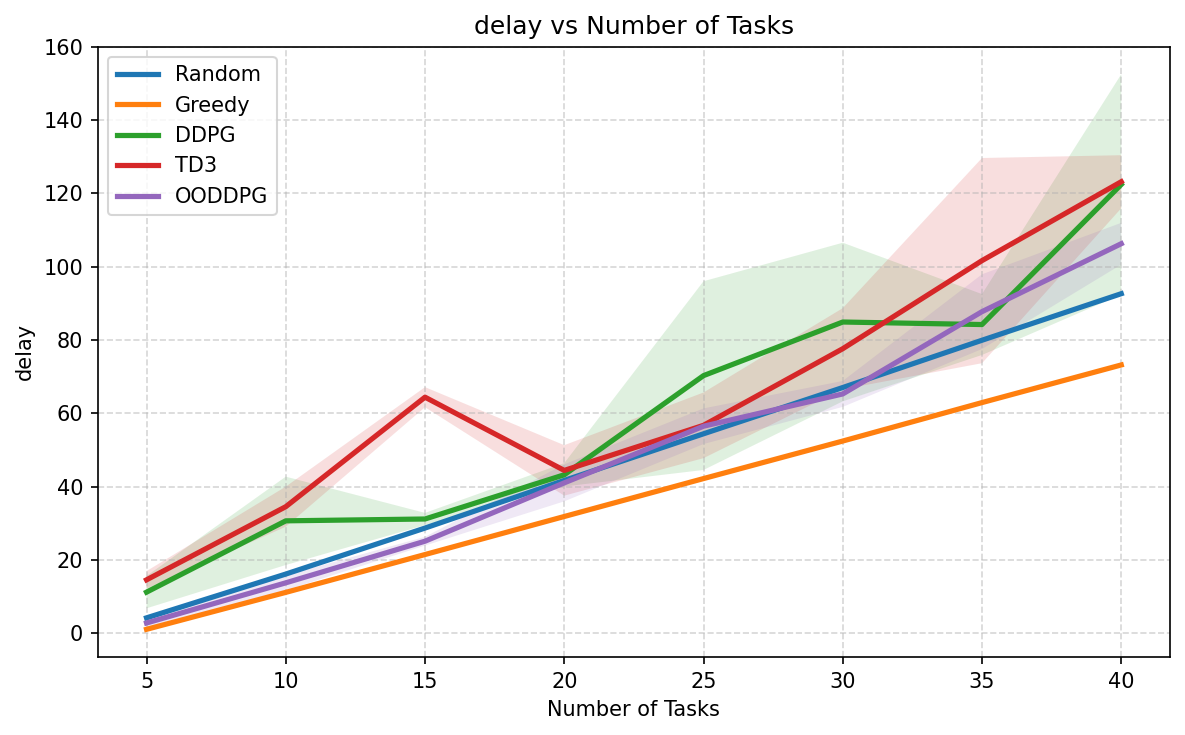

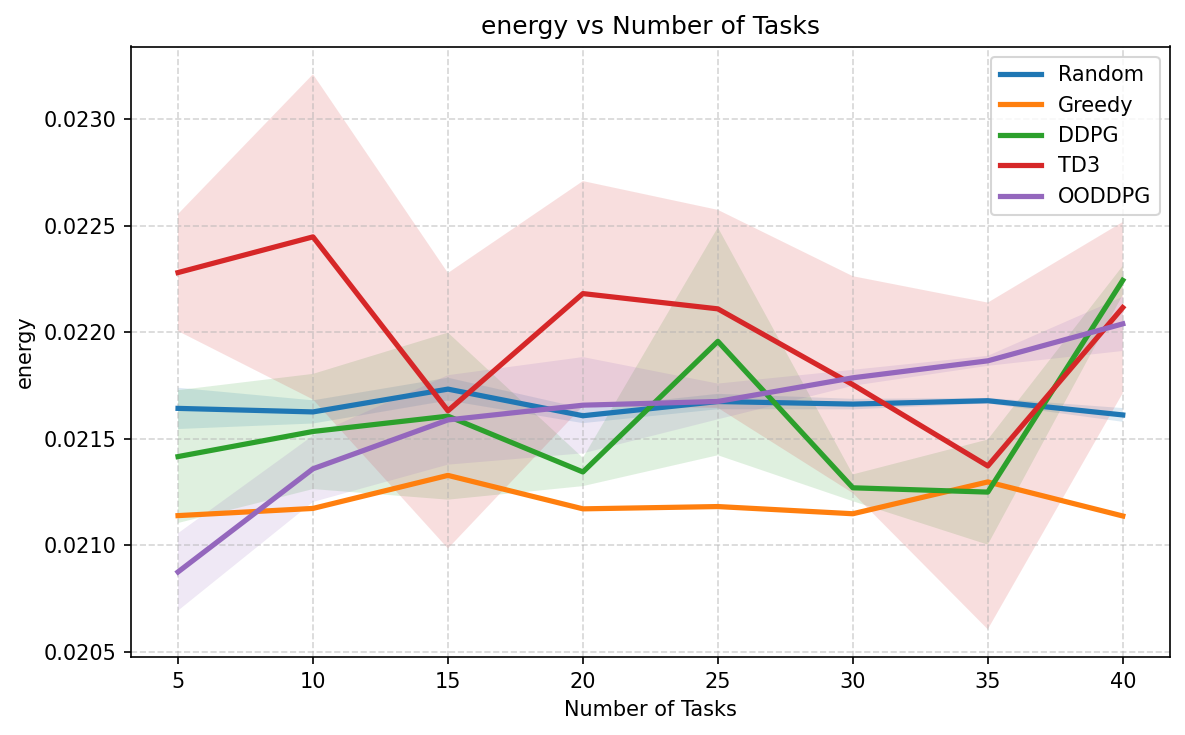

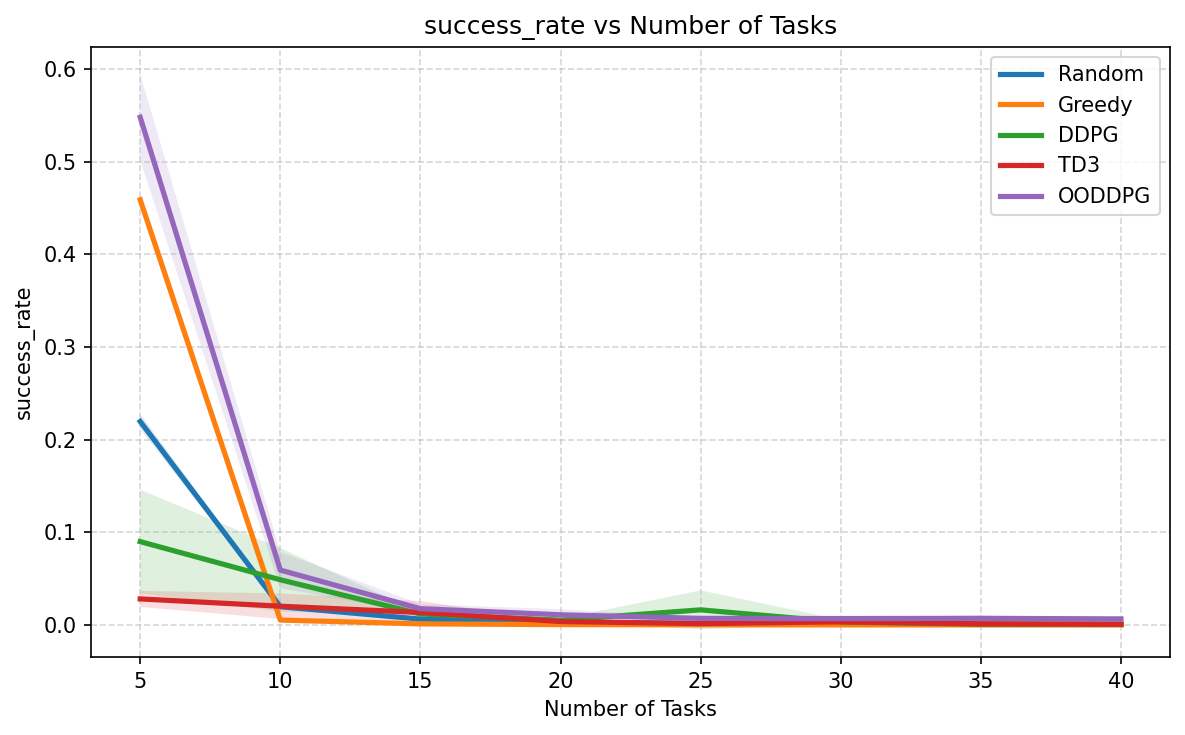

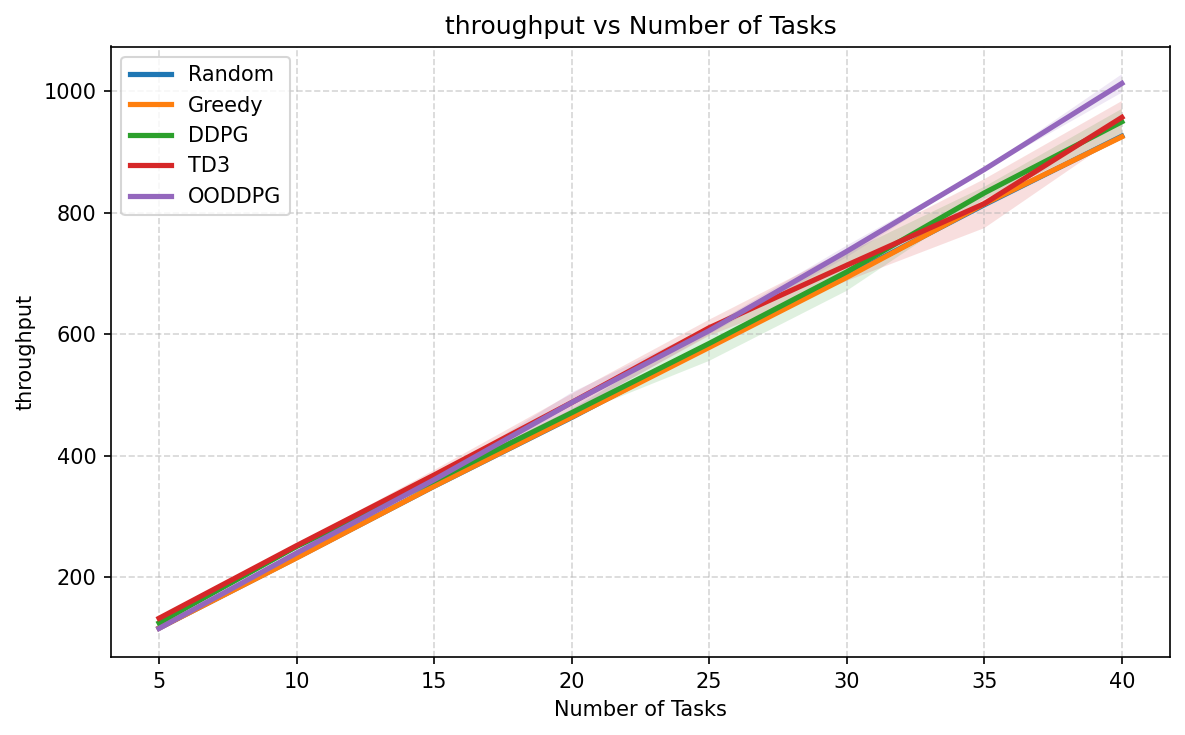

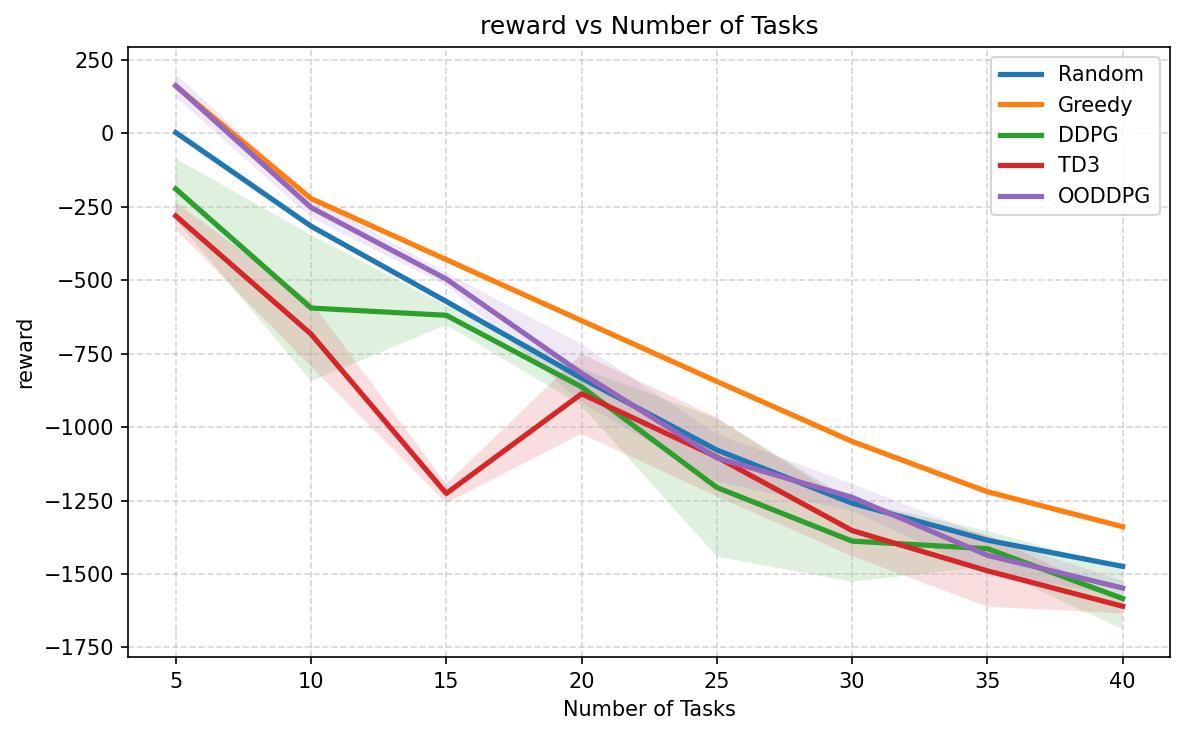



[2/7] SERVER SCALING EXPERIMENT


SERVERS = 2

========== Random ==========
Seed = 0
Seed = 1
Seed = 2

========== Greedy ==========
Seed = 0
Seed = 1
Seed = 2


Output()


========== DDPG ==========
Seed = 0


Output()

Seed = 1


...

Output()

Seed = 1


Output()

Seed = 2



========== OODDPG ==========
Seed = 0
Seed = 1
Seed = 2


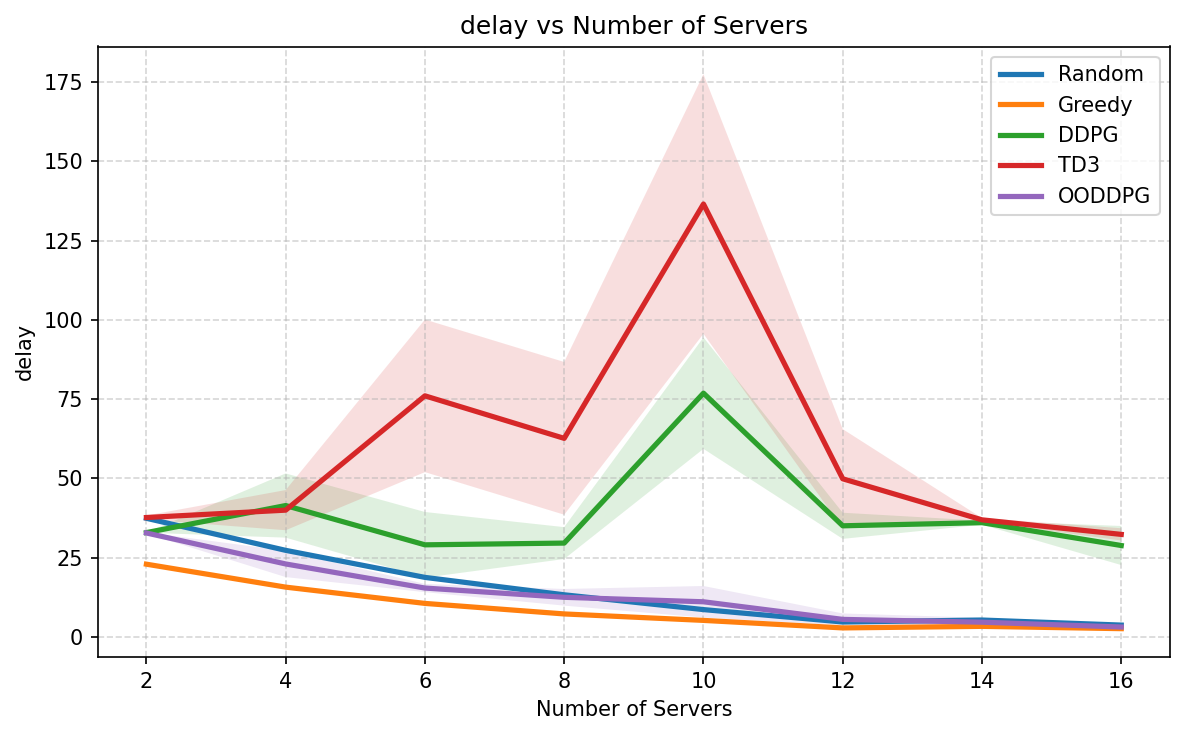

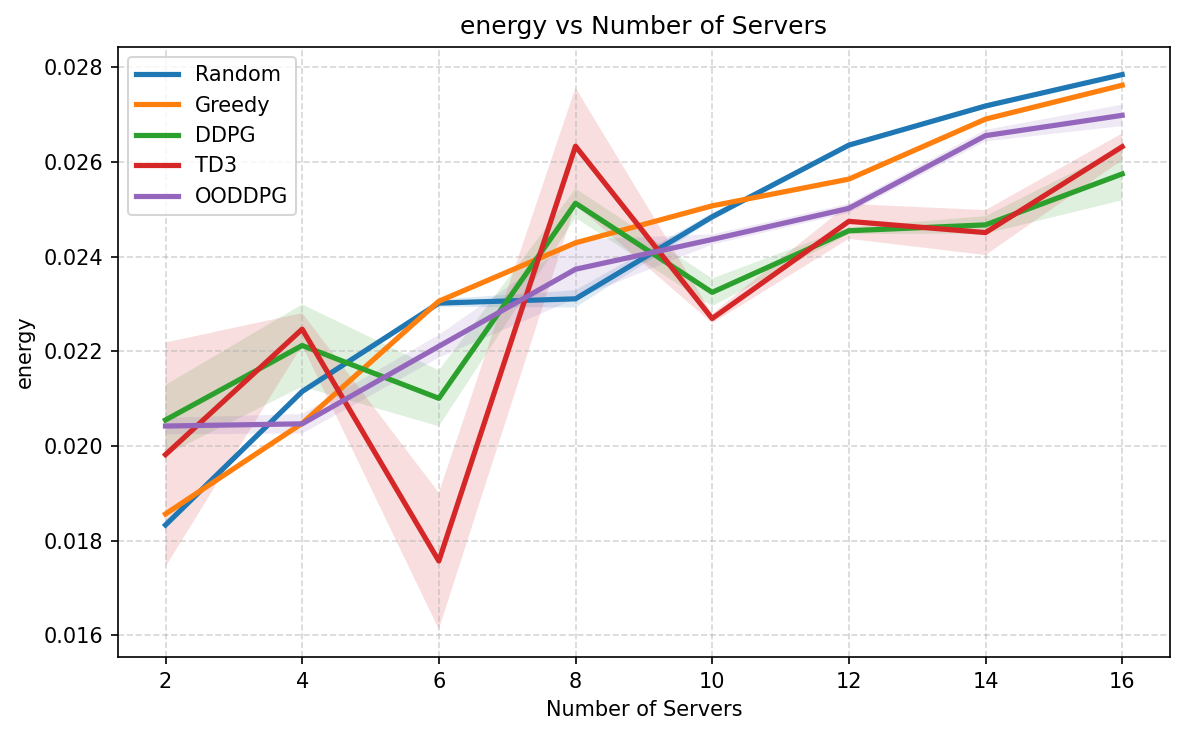

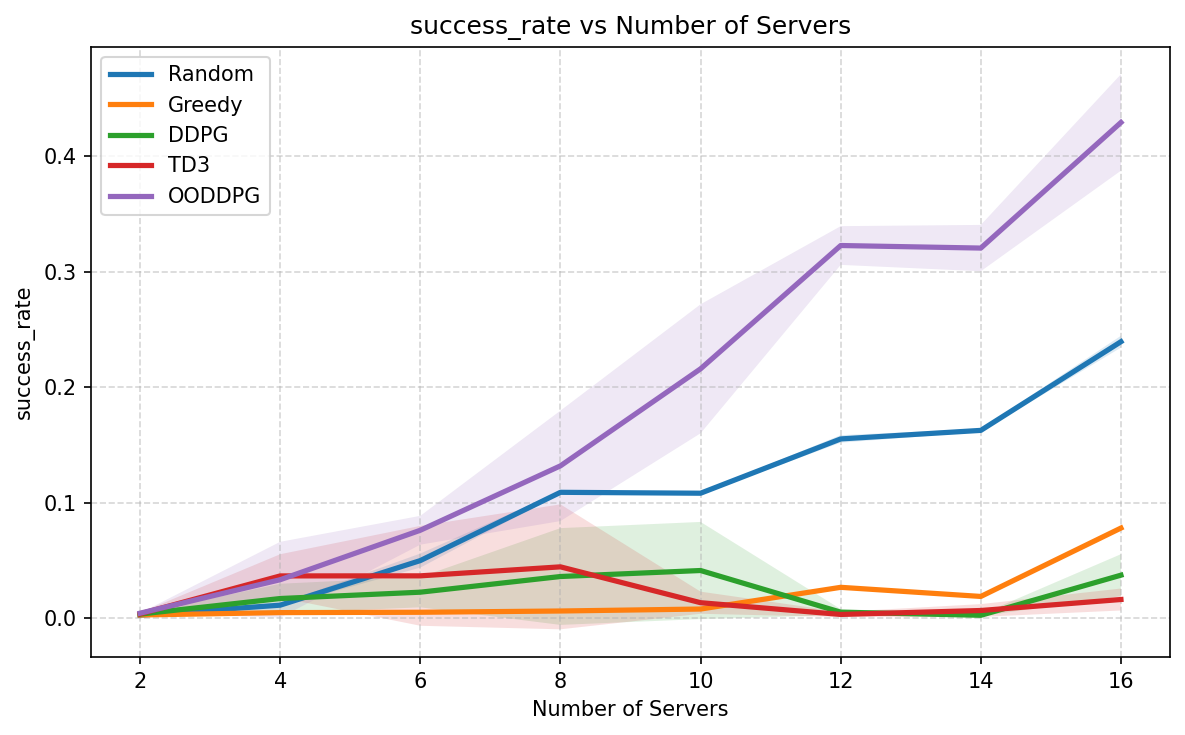

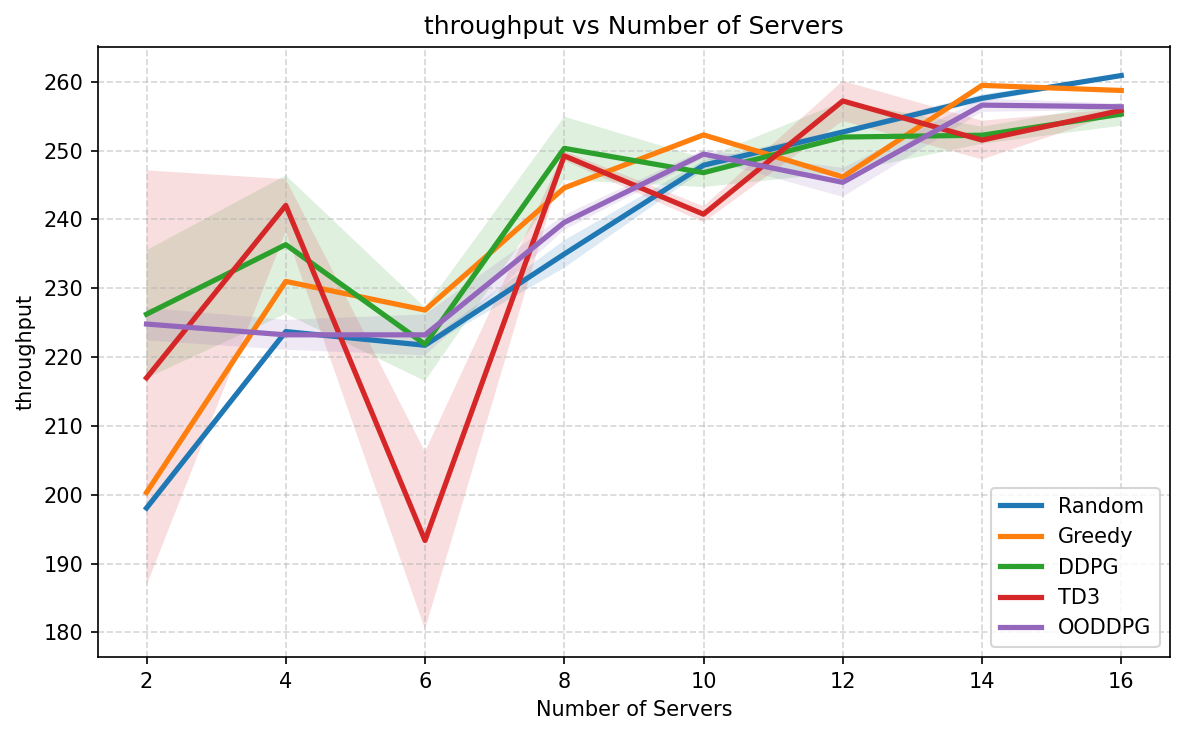

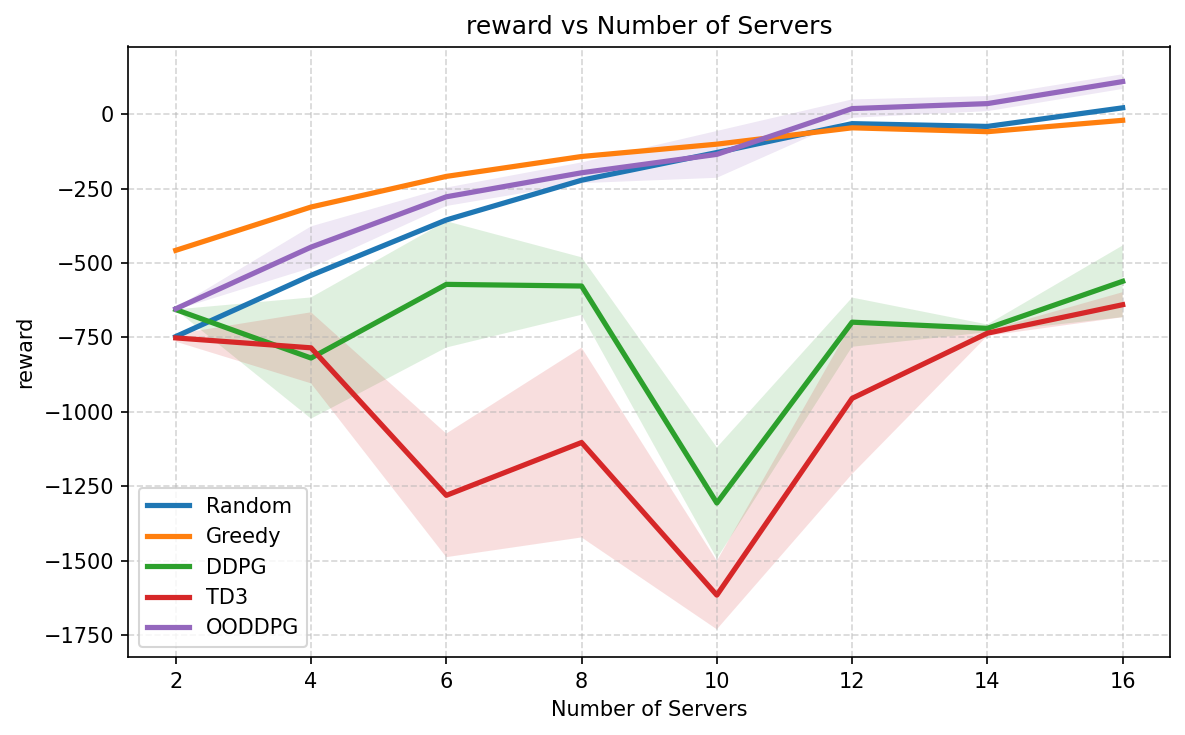



[3/7] BANDWIDTH SENSITIVITY EXPERIMENT


BANDWIDTH = 0.25

========== Random ==========
Seed = 0
Seed = 1
Seed = 2

========== Greedy ==========
Seed = 0
Seed = 1
Seed = 2


Output()


========== DDPG ==========
Seed = 0


Output()

Seed = 1


...

Output()

Seed = 1


Output()

Seed = 2



========== OODDPG ==========
Seed = 0


In [ ]:
# =========================================================
# RUN ALL EXPERIMENTS
# =========================================================

print("\n" + "="*60)
print("STARTING FULL PAPER REPRODUCTION SUITE")
print("="*60)

# =========================================================
# 1. TASK SCALING
# =========================================================

print("\n\n[1/7] TASK SCALING EXPERIMENT")

experiment_num_tasks()

# =========================================================
# 2. SERVER SCALING
# =========================================================

print("\n\n[2/7] SERVER SCALING EXPERIMENT")

experiment_num_servers()

# =========================================================
# 3. BANDWIDTH SENSITIVITY
# =========================================================

print("\n\n[3/7] BANDWIDTH SENSITIVITY EXPERIMENT")

experiment_bandwidth()

# =========================================================
# 4. DEADLINE SENSITIVITY
# =========================================================

print("\n\n[4/7] DEADLINE SENSITIVITY EXPERIMENT")

experiment_deadlines()

# =========================================================
# 5. TRAFFIC LOAD STRESS TEST
# =========================================================

print("\n\n[5/7] TRAFFIC LOAD STRESS TEST")

experiment_traffic_load()

# =========================================================
# 6. SCALABILITY ANALYSIS
# =========================================================

print("\n\n[6/7] SCALABILITY ANALYSIS")

experiment_scalability()

# =========================================================
# 7. CONVERGENCE ANALYSIS
# =========================================================

print("\n\n[7/7] TRAINING CONVERGENCE")

convergence_experiment()

# =========================================================
# FINISHED
# =========================================================

print("\n" + "="*60)
print("ALL EXPERIMENTS FINISHED")
print("="*60)

In [ ]:
COUNTIFS('Simulation Table'!$H$2:H2,"="&'Simulation Table'!$H$2) - COUNTIFS('Simulation Table'!$K$2:K2,"<="&F2,'Simulation Table'!$K$2:K2,">0") - COUNTIFS('Simulation Table'!$N$2:N2,"<="&F2,'Simulation Table'!$N$2:N2,">0")-IF(MAX('Simulation Table'!$K$2:K2)>F2,1,0)-IF(MAX('Simulation Table'!$N$2:N2)>F2,1,0)

In [ ]:
=COUNTIFS('Simulation Table'!$H$2:H2,"="&'Simulation Table'!$H$2)-COUNTIFS('Simulation Table'!$K$2:K2,"<="&'Simulation Table'!E3,'Simulation Table'!$K$2:K2,">0")-COUNTIFS('Simulation Table'!$N$2:N2,"<="&'Simulation Table'!E3,'Simulation Table'!$N$2:N2,">0")-IF(MAX('Simulation Table'!$K$2:K2)>E3,1,0)-IF(MAX('Simulation Table'!$N$2:N2)>E3,1,0)


Servers = 2


Output()


Training DDPG ...


Output()


Training OODDPG ...

Servers = 4


...

Output()


Training DDPG ...


Output()


Training TD3 ...



Training OODDPG ...


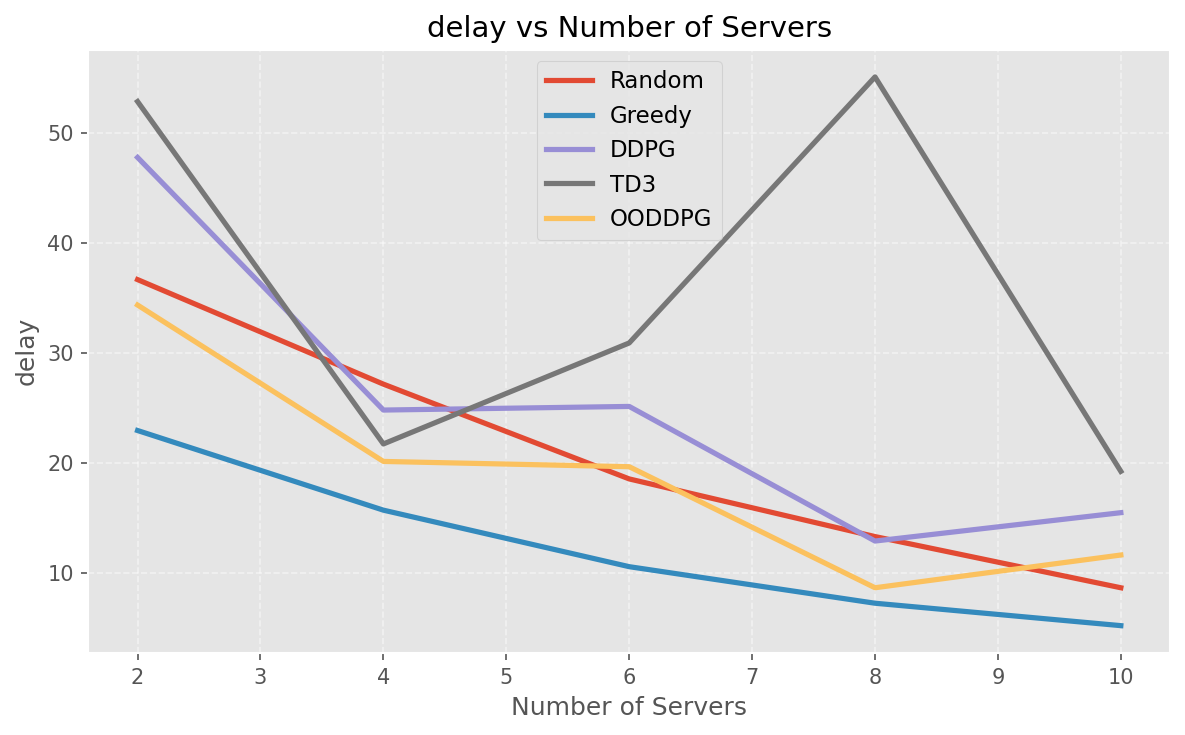

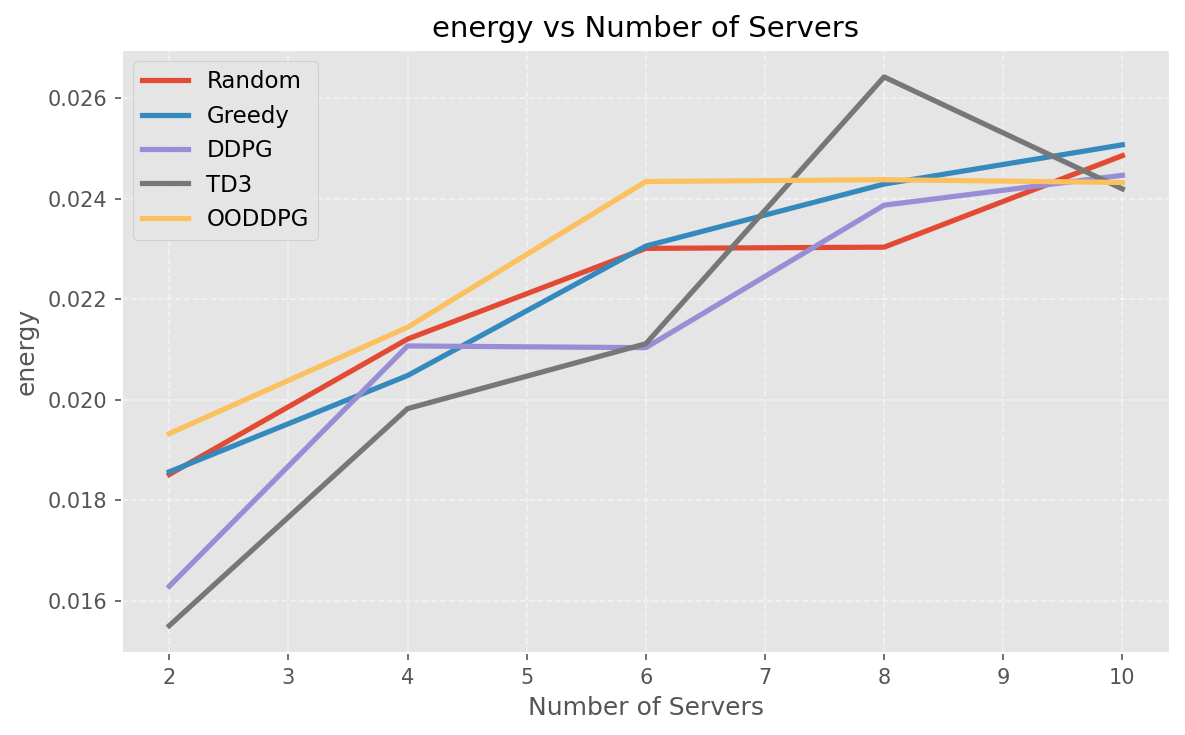

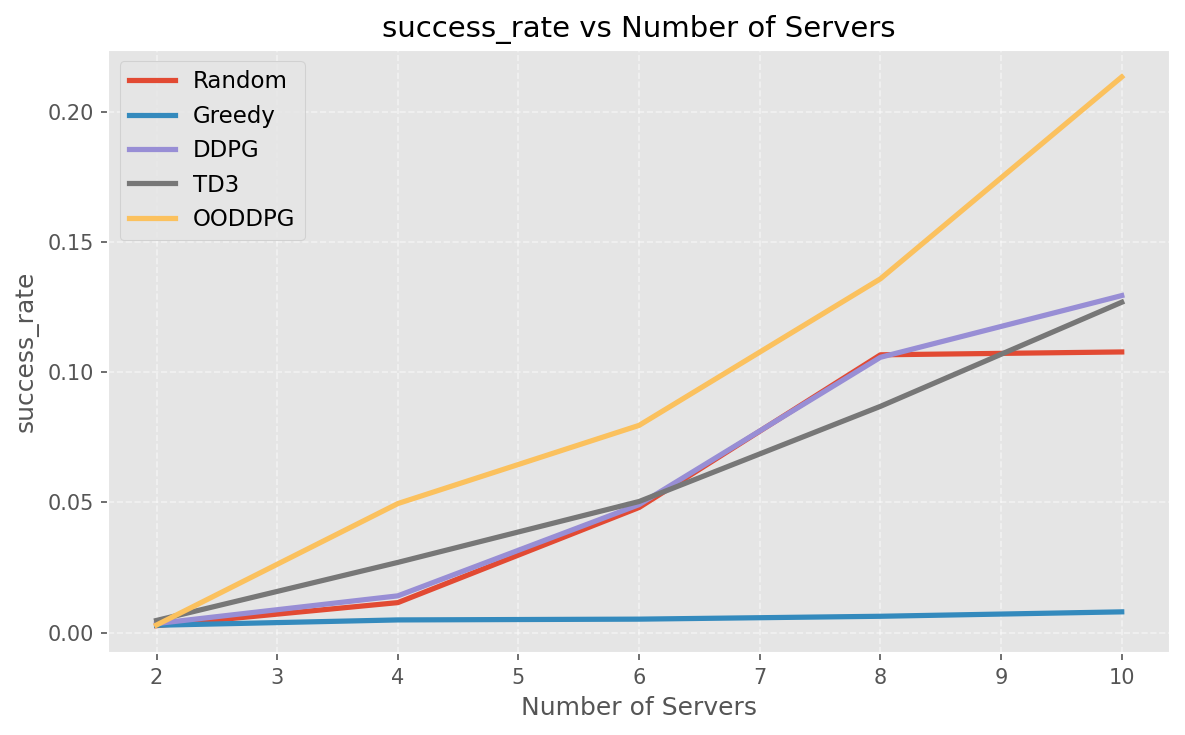

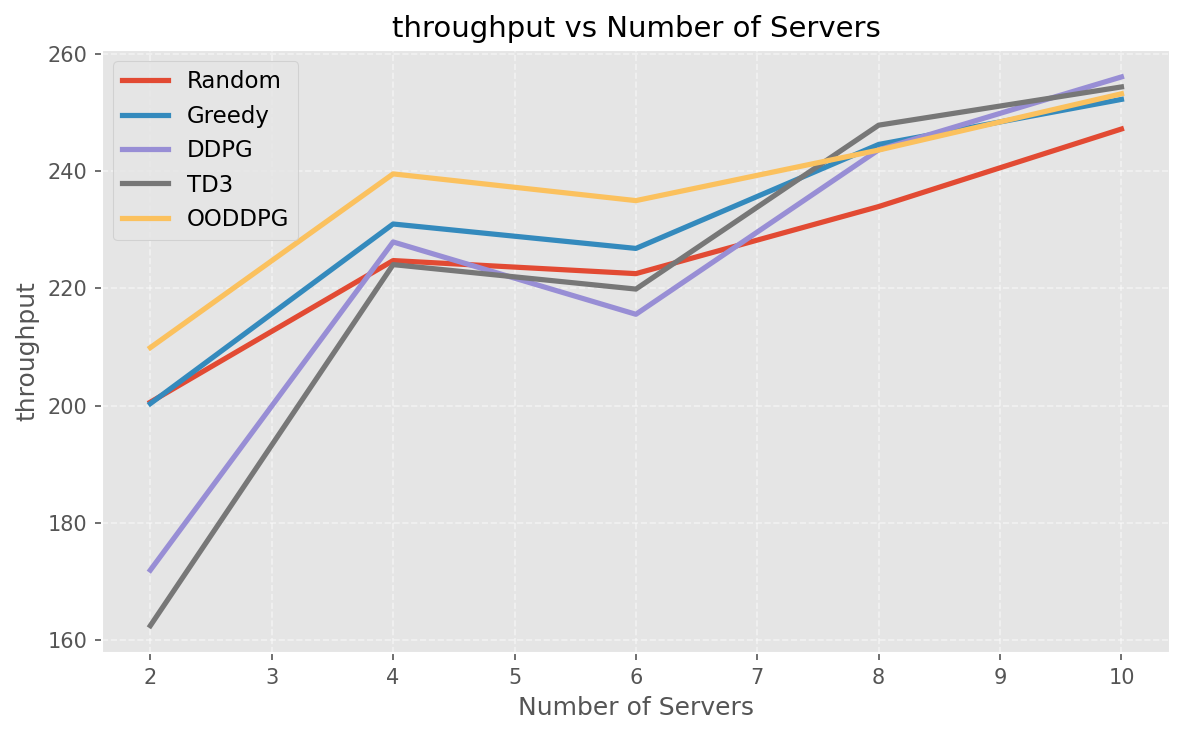


Tasks = 5


Output()


Training DDPG ...


Output()


Training TD3 ...


...

Output()


Training DDPG ...


Output()


Training TD3 ...



Training OODDPG ...


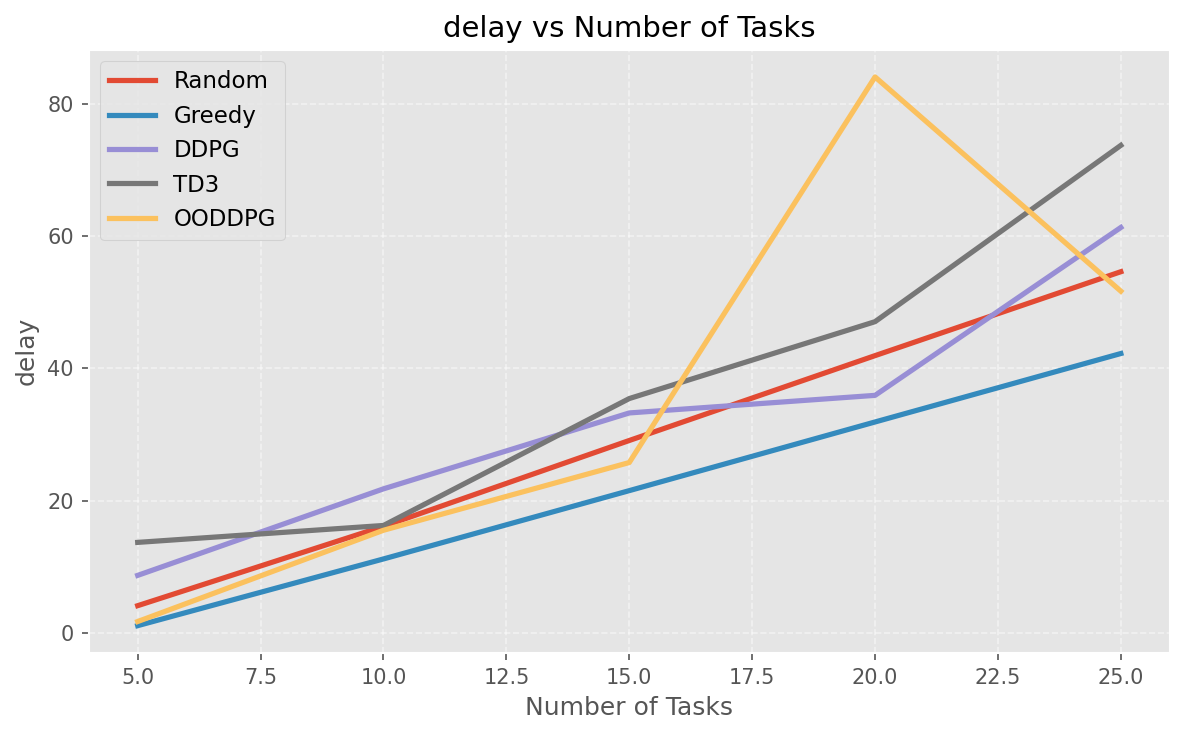

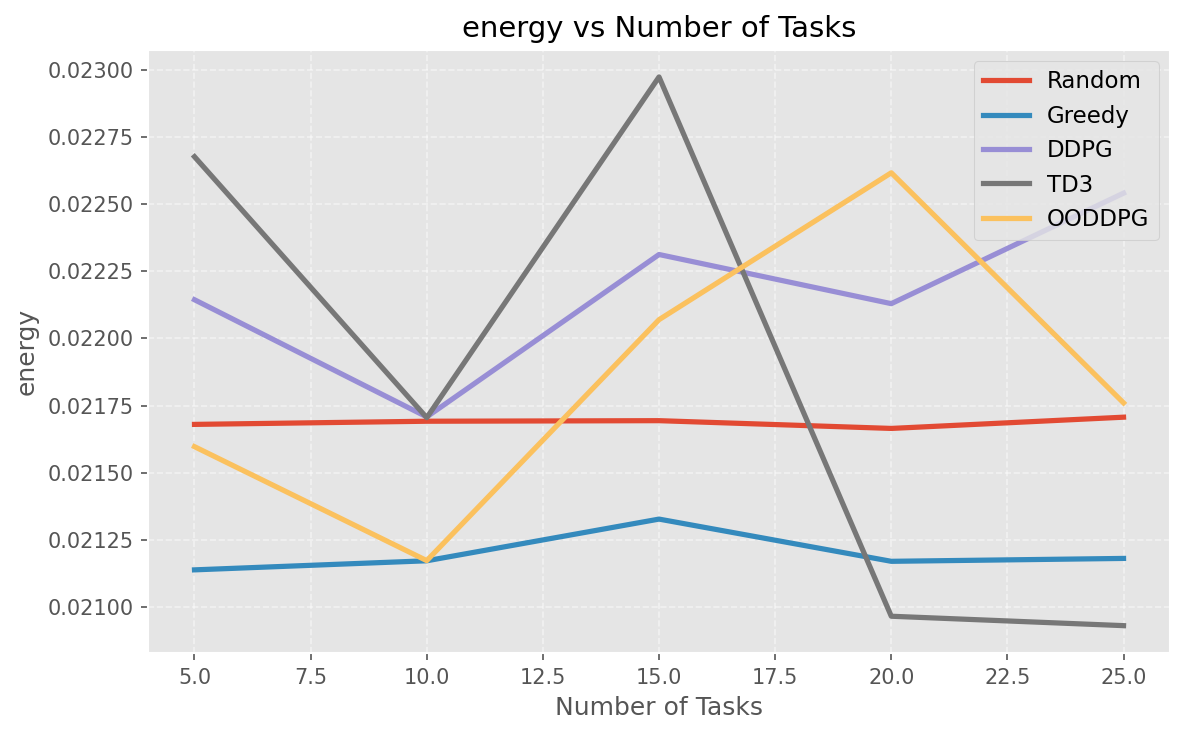

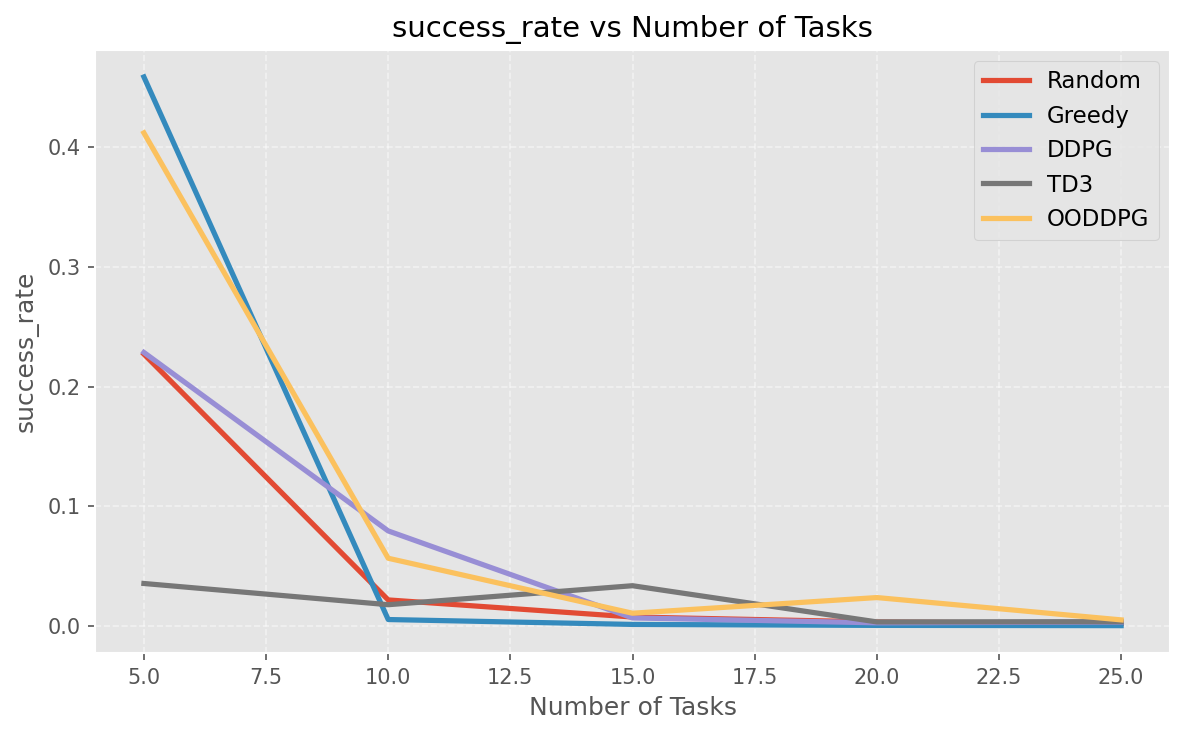

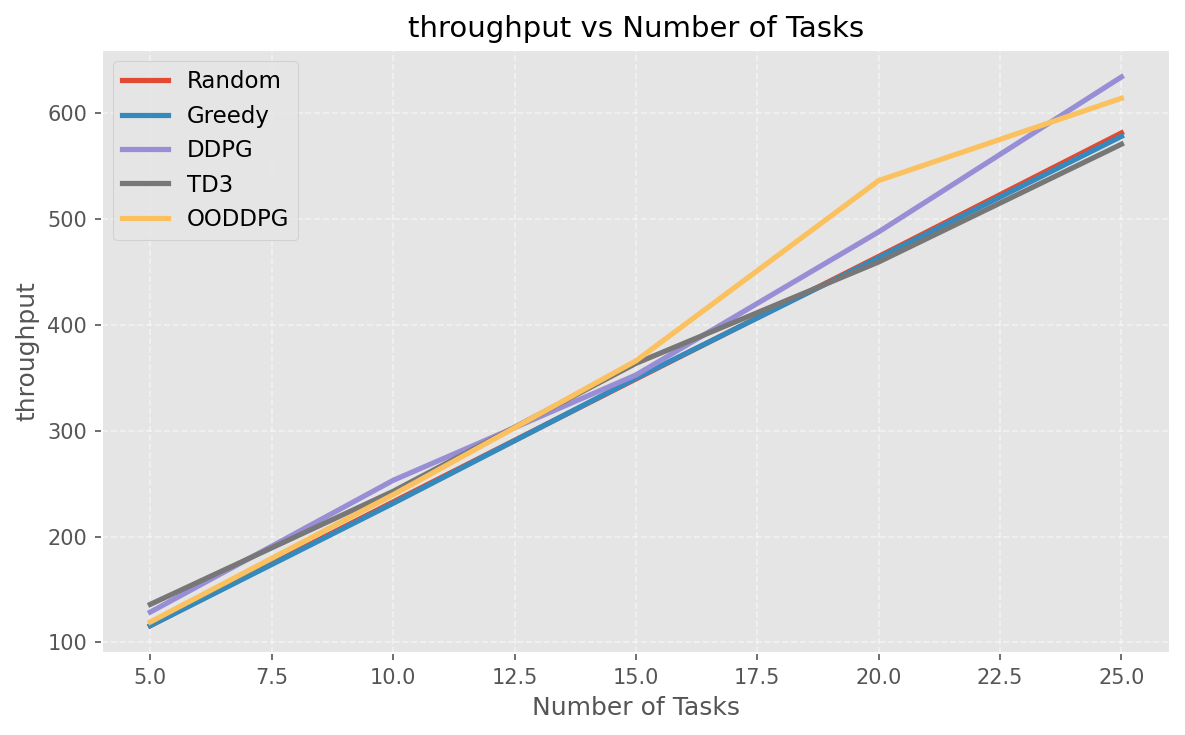


Bandwidth Scale = 0.5


Output()


Training DDPG ...


Output()


Training TD3 ...


...

Output()


Training DDPG ...


Output()


Training TD3 ...



Training OODDPG ...


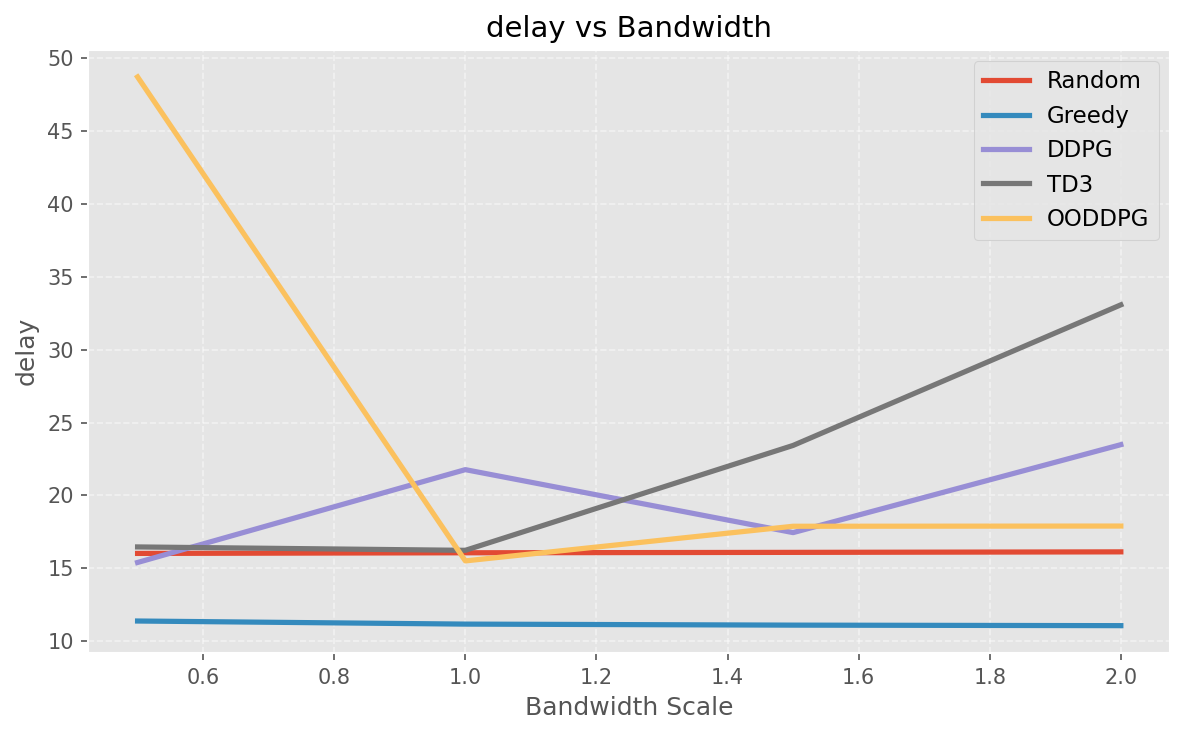

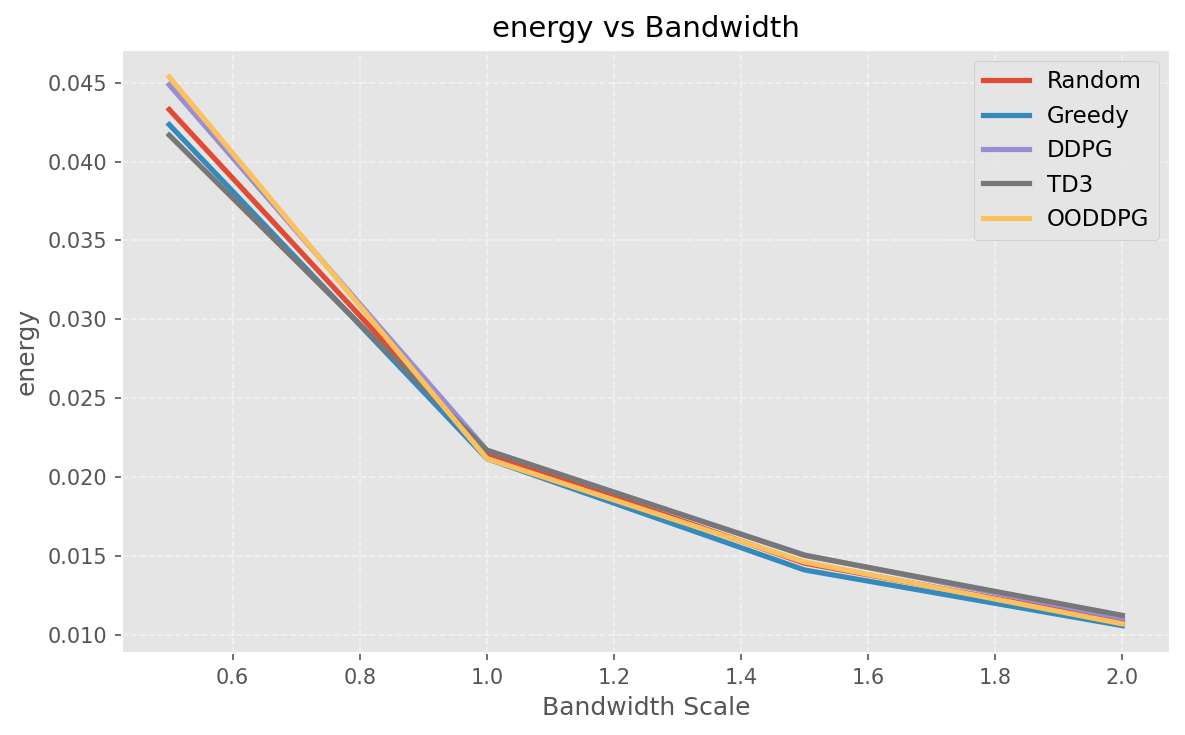

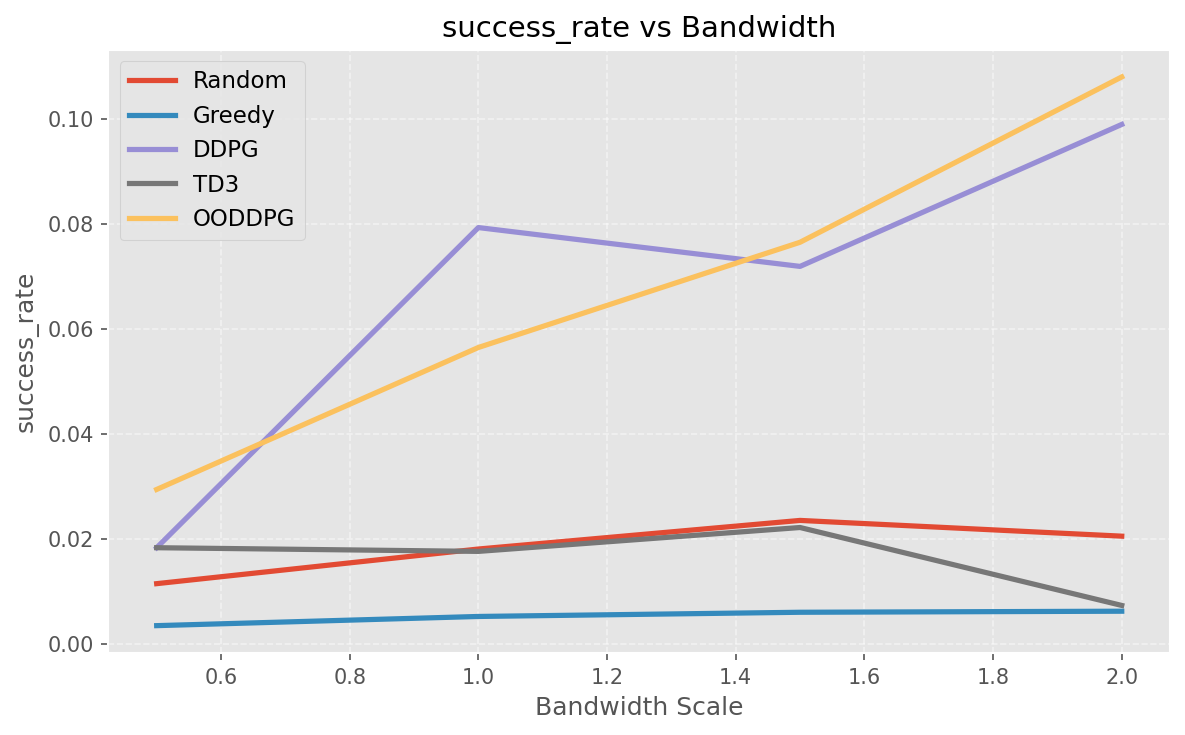

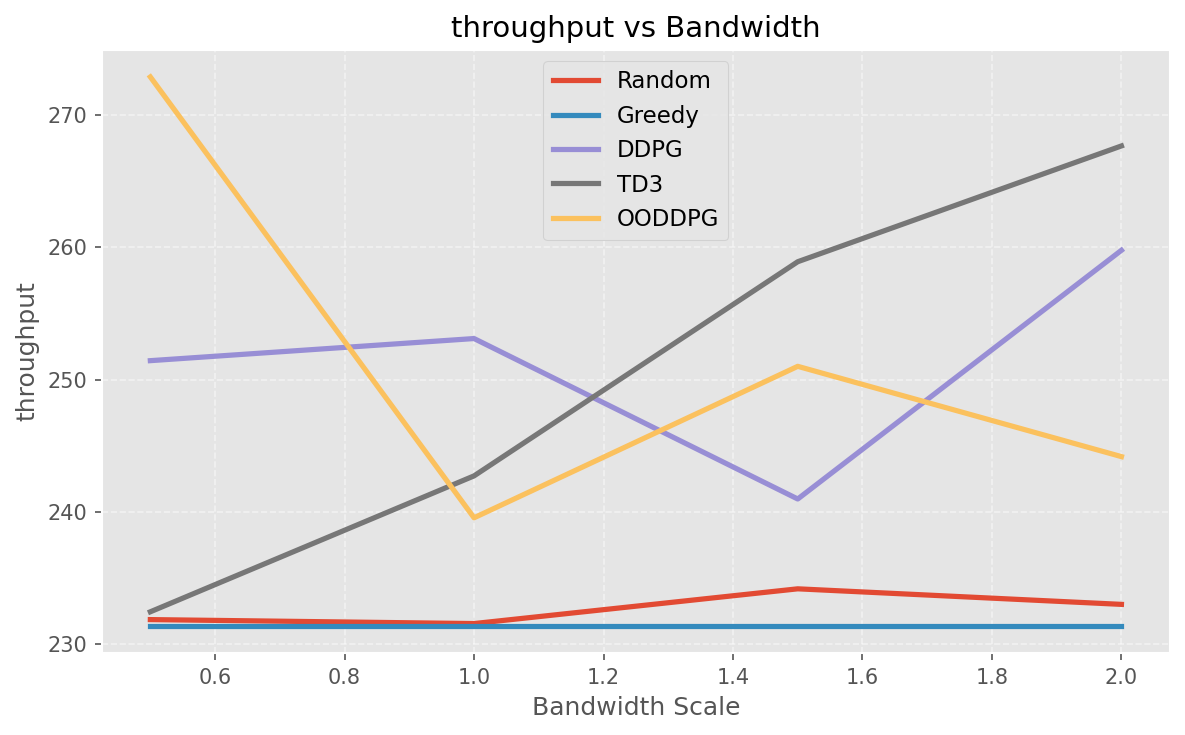

Output()

Output()

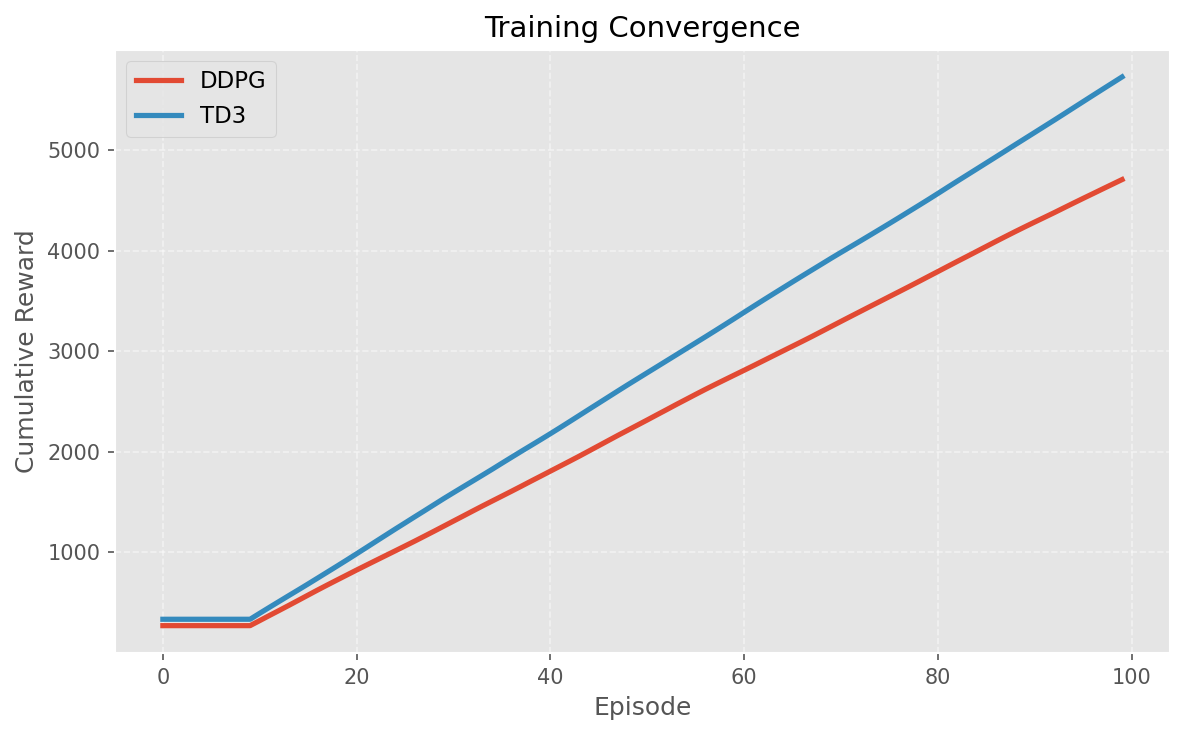

In [17]:
experiment_num_servers()

experiment_num_tasks()

experiment_bandwidth()

convergence_experiment()